# Notebook Collection Overview
A quick visualization of all the `.ipynb` files in this directory.

In [1]:
import glob, os, json, datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Gather all .ipynb files (skip checkpoints)
nb_dir = "/Users/kylekelley/notebooks"
files = [
    f
    for f in glob.glob(os.path.join(nb_dir, "**/*.ipynb"), recursive=True)
    if ".ipynb_checkpoints" not in f
]

# Extract metadata
notebooks = []
for f in files:
    stat = os.stat(f)
    rel = os.path.relpath(f, nb_dir)
    subfolder = os.path.dirname(rel) or "root"
    # Try to get kernel language
    try:
        with open(f) as fh:
            meta = json.load(fh)
        lang = meta.get("metadata", {}).get("kernelspec", {}).get("language", "unknown")
    except Exception:
        lang = "unknown"
    notebooks.append(
        {
            "name": os.path.basename(f),
            "path": rel,
            "folder": subfolder,
            "language": lang,
            "modified": datetime.datetime.fromtimestamp(stat.st_mtime),
            "size_kb": stat.st_size / 1024,
        }
    )

print(f"Found {len(notebooks)} notebooks (excluding checkpoints)")

Found 66 notebooks (excluding checkpoints)


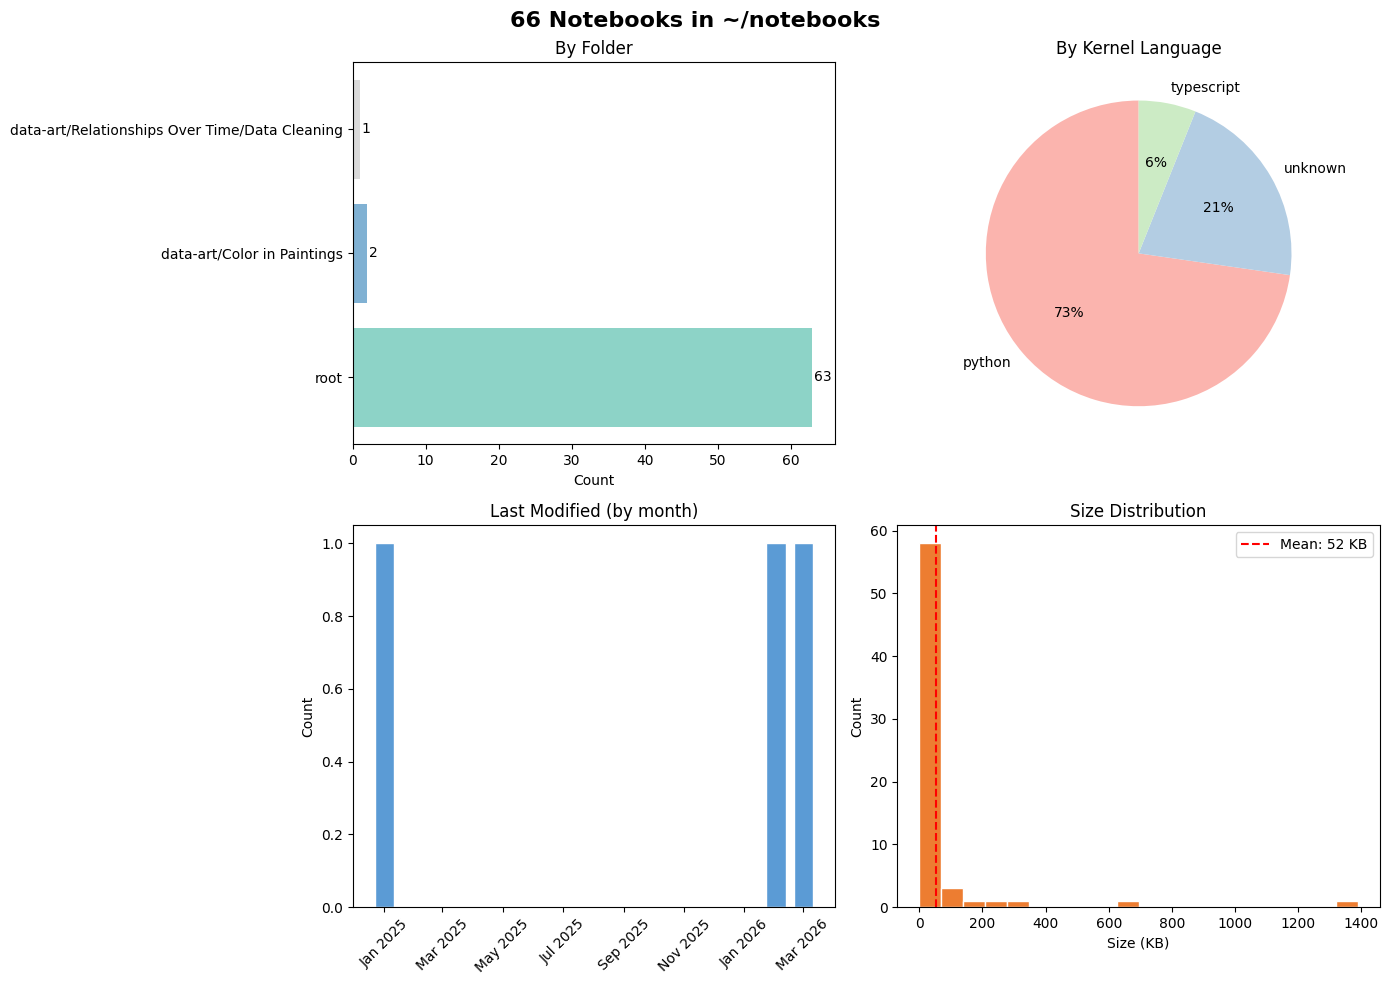

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"{len(notebooks)} Notebooks in ~/notebooks", fontsize=16, fontweight="bold"
)

# 1. By folder
from collections import Counter

folder_counts = Counter(nb["folder"] for nb in notebooks)
folders, counts = zip(*folder_counts.most_common())
colors_folder = plt.cm.Set3([i / len(folders) for i in range(len(folders))])
axes[0, 0].barh(folders, counts, color=colors_folder)
axes[0, 0].set_title("By Folder")
axes[0, 0].set_xlabel("Count")
for i, v in enumerate(counts):
    axes[0, 0].text(v + 0.2, i, str(v), va="center", fontsize=10)

# 2. By language/kernel
lang_counts = Counter(nb["language"] for nb in notebooks)
langs, lcounts = zip(*lang_counts.most_common())
axes[0, 1].pie(
    lcounts,
    labels=langs,
    autopct="%1.0f%%",
    startangle=90,
    colors=plt.cm.Pastel1.colors,
)
axes[0, 1].set_title("By Kernel Language")

# 3. Timeline — notebooks by month modified
months = [nb["modified"].replace(day=1) for nb in notebooks]
month_counts = Counter(months)
sorted_months = sorted(month_counts.keys())
sorted_counts = [month_counts[m] for m in sorted_months]
axes[1, 0].bar(
    sorted_months, sorted_counts, width=20, color="#5B9BD5", edgecolor="white"
)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].set_title("Last Modified (by month)")
axes[1, 0].set_ylabel("Count")

# 4. Size distribution
sizes = [nb["size_kb"] for nb in notebooks]
axes[1, 1].hist(sizes, bins=20, color="#ED7D31", edgecolor="white")
axes[1, 1].set_title("Size Distribution")
axes[1, 1].set_xlabel("Size (KB)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].axvline(
    sum(sizes) / len(sizes),
    color="red",
    linestyle="--",
    label=f"Mean: {sum(sizes) / len(sizes):.0f} KB",
)
axes[1, 1].legend()

plt.tight_layout()
plt.show()